In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Chargement des données (Chemin pour dossier /notebooks)
path = '../data/insurance.csv'

if os.path.exists(path):

    dtype_dict = {'age': 'int32', 'sex': 'category', 'bmi': 'float32', 'children': 'int32', 'smoker': 'category', 'region': 'object', 'charges': 'float64'}

    df = pd.read_csv(path, low_memory=True, dtype=dtype_dict)
    print(df.dtypes)
    print(" Les données sont prêtes pour l'analyse de la Semaine 1.")
    print(f"Dataset : {df.shape[0]} lignes et {df.shape[1]} colonnes.")
else:
    print(f" Erreur : Je ne trouve pas le fichier au chemin : {path}")
    print("Vérifie bien que ton notebook est dans  le dossier 'notebooks'.")


df.isna().sum()

Succès ! Les données sont prêtes pour l'analyse de la Semaine 1.
Dataset : 1338 lignes et 7 colonnes.


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
# 3 Informations sur le DataFrame
# contrôle des doublons
df.duplicated().sum()

# Visualiser le doublon
df[df.duplicated()]

# Vérifier doublons sur les colonnes clés
df.duplicated(subset=["age","sex","bmi","children","smoker","region"]).sum()

# Voir toutes les lignes concernées
df[df.duplicated(keep=False)]

# Suppression des doublons
df = df.drop_duplicates()

# Vérification après suppression
df.duplicated().sum()





np.int64(0)

In [11]:
# Statistiques de base : mean, median, std, min, max, quartiles
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
# Nombre de valeurs uniques par colonne
df.nunique()



region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [14]:
# Comptage des valeurs pour une colonne catégorielle
df['smoker'].value_counts()
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Optionnel : style seaborn
sns.set(style="whitegrid")


In [3]:
# Chemin vers ton dataset
path = '../data/insurance.csv'

dtype_dict = {
    'age': 'int32', 'sex': 'category', 'bmi': 'float32',
    'children': 'int32', 'smoker': 'category', 'region': 'object',
    'charges': 'float64'
}

df = pd.read_csv(path, dtype=dtype_dict)


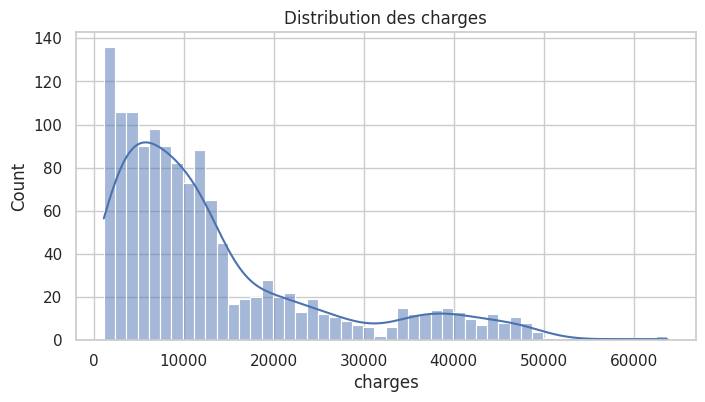

In [ ]:
# Charges
plt.figure(figsize=(8,4))
sns.histplot(df['charges'], bins=50, kde=True)
plt.title("Distribution des charges")
plt.show()

#1️Histogramme des charges
# Montre la distribution des charges d’assurance.
# Observation : majorité des charges autour de 10 000$, quelques outliers très élevés (>50 000$), distribution asymétrique à droite.
# Conclusion : certaines valeurs extrêmes pourraient influencer un modèle, envisager une transformation log.

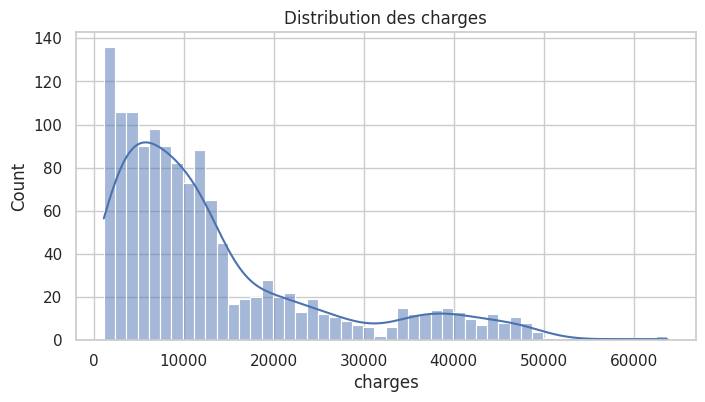

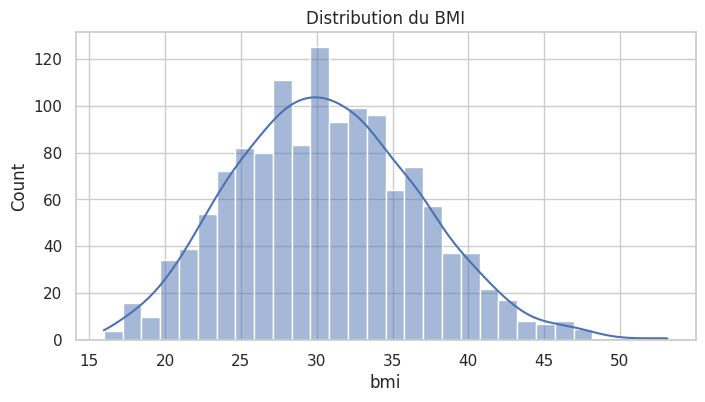

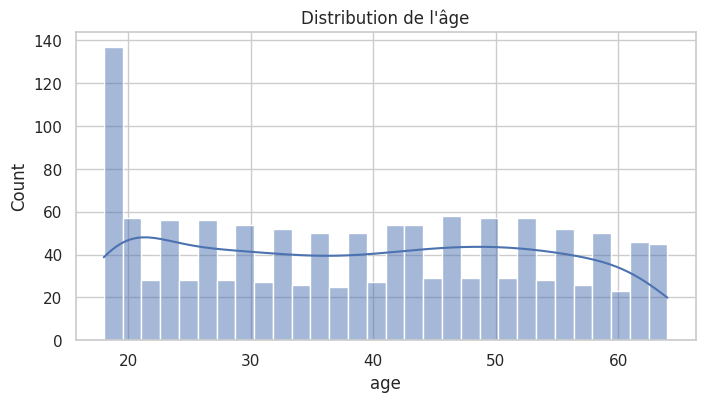

In [15]:
# 1️ Histogramme des charges
# Montre la distribution des charges d’assurance.
# Observation : majorité des charges autour de 10 000$, quelques outliers très élevés (>50 000$), distribution asymétrique à droite.
# Conclusion : certaines valeurs extrêmes pourraient influencer un modèle, envisager une transformation log.
plt.figure(figsize=(8,4))
sns.histplot(df['charges'], bins=50, kde=True)
plt.title("Distribution des charges")
plt.show()


# 2️ Histogramme du BMI
# Montre la distribution de l’indice de masse corporelle (BMI).
# Observation : la plupart des assurés ont un BMI entre 20 et 35, quelques valeurs extrêmes plausibles.
# Conclusion : valeurs cohérentes, pas besoin de nettoyage, mais noter quelques outliers.
plt.figure(figsize=(8,4))
sns.histplot(df['bmi'], bins=30, kde=True)
plt.title("Distribution du BMI")
plt.show()


# 3️ Histogramme de l’âge
# Montre la répartition des âges.
# Observation : âge entre 18 et 64 ans, distribution assez normale.
# Conclusion : variable propre et cohérente, pas de valeurs aberrantes.
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Distribution de l'âge")
plt.show()




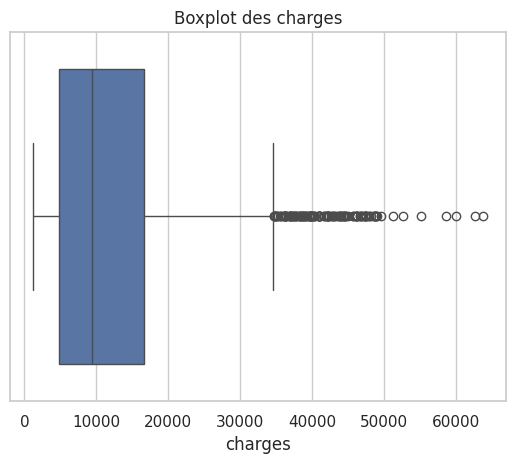

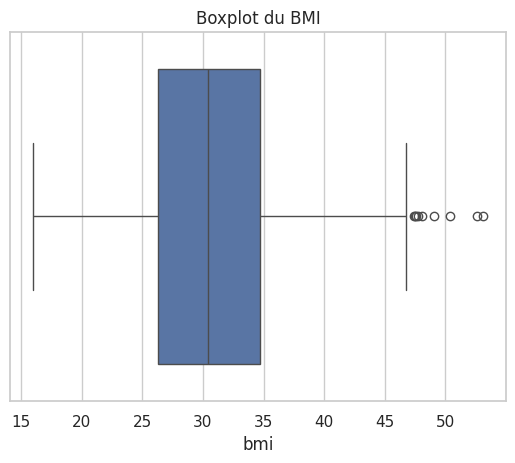

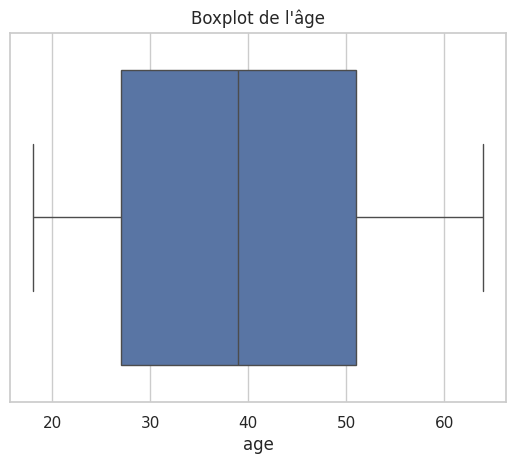

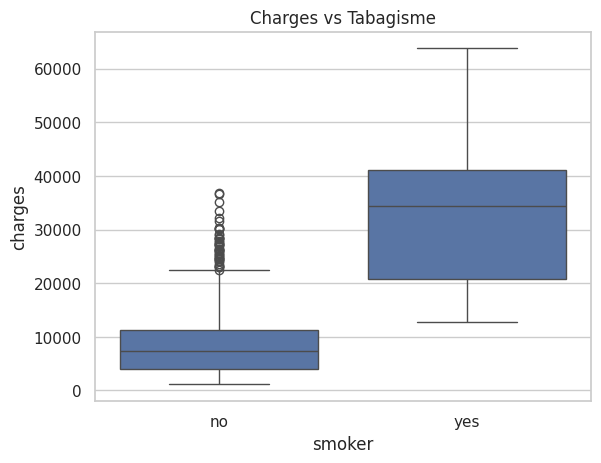

In [12]:
# 1️Boxplot des charges
# Visualise la médiane, les quartiles et les outliers pour les charges.
# Observation : la majorité des charges est concentrée autour de 10 000$, mais il existe plusieurs outliers très élevés (>50 000$).
# Conclusion : ces valeurs extrêmes pourraient influencer un modèle linéaire. On pourrait envisager une transformation log pour réduire l'effet des outliers.

sns.boxplot(x=df['charges'])
plt.title("Boxplot des charges")
plt.show()


#2️ Boxplot du BMI
# Montre la distribution du BMI avec médiane, quartiles et outliers.
# Observation : la plupart des individus ont un BMI entre 20 et 35, quelques valeurs extrêmes au-delà de 50.
# Conclusion : les valeurs sont plausibles, mais les outliers doivent être notés pour l'analyse et éventuellement le scaling.

sns.boxplot(x=df['bmi'])
plt.title("Boxplot du BMI")
plt.show()


# 3️ Boxplot de l'âge
# Visualise la répartition de l'âge.
# Observation : âge compris entre 18 et 64 ans, distribution plutôt normale, peu d’outliers.
# Conclusion : variable propre et cohérente, pas besoin de nettoyage.

sns.boxplot(x=df['age'])
plt.title("Boxplot de l'âge")
plt.show()


# 4️ Boxplot Charges vs Tabagisme
# Compare les charges entre fumeurs et non-fumeurs.
# Observation : les fumeurs ont des charges beaucoup plus élevées que les non-fumeurs, avec des outliers encore plus extrêmes.
# Conclusion : tabagisme est un facteur clé pour expliquer les charges. Cette variable doit absolument être incluse dans le modèle.
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges vs Tabagisme")
plt.show()



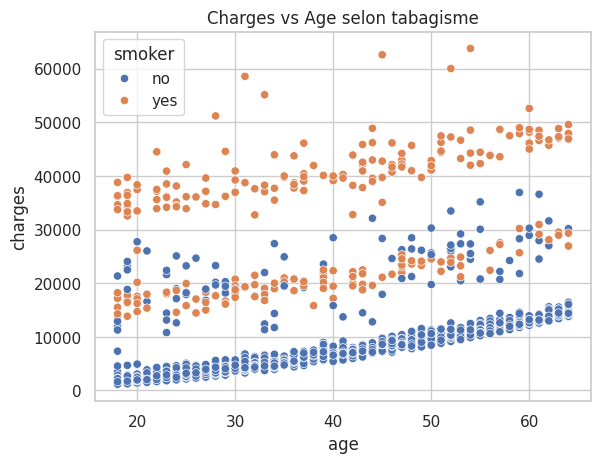

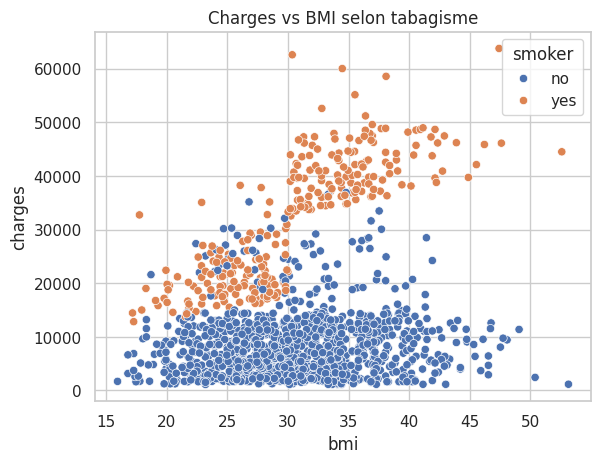

In [11]:
# 1️Scatterplot Charges vs Age
# Visualise la relation entre l'âge et les charges, en différenciant fumeurs et non-fumeurs.
# Observation : 
# - Pour les non-fumeurs, les charges restent relativement faibles et ne varient pas beaucoup avec l'âge.
# - Pour les fumeurs, les charges augmentent avec l'âge, et il existe des outliers très élevés.
# Conclusion : l'effet de l'âge sur les charges dépend fortement du tabagisme. 
# Cette interaction age × smoker sera importante à prendre en compte dans le modèle.

sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title("Charges vs Age selon tabagisme")
plt.show()


#2️ Scatterplot Charges vs BMI
# Visualise la relation entre le BMI et les charges, en différenciant fumeurs et non-fumeurs.
# Observation : 
# - Pour les non-fumeurs, charges modérées, légère augmentation avec BMI.
# - Pour les fumeurs, charges augmentent plus fortement avec BMI, avec plusieurs outliers extrêmes.
# Conclusion : le BMI impacte surtout les fumeurs. L'interaction BMI × smoker est un facteur important pour prédire les charges.

sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title("Charges vs BMI selon tabagisme")
plt.show()



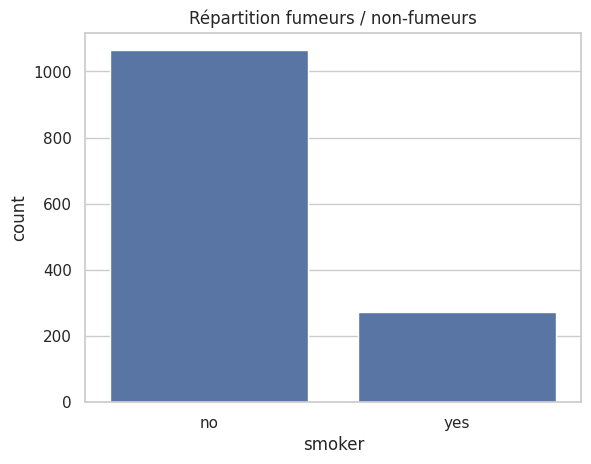

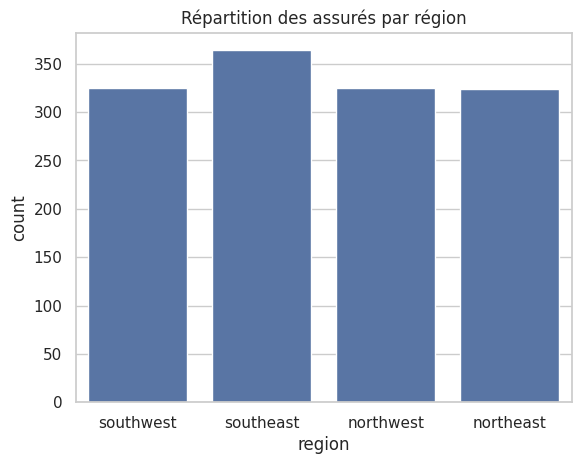

In [ ]:
# 1️ Répartition fumeurs / non-fumeurs
# Visualise le nombre d'individus fumeurs et non-fumeurs.
# Observation : environ 80% des assurés sont non-fumeurs et 20% sont fumeurs.
# Conclusion : la variable "smoker" est déséquilibrée mais très importante pour expliquer les charges. 
# Elle devra être incluse dans le modèle et pourrait influencer la prédiction fortement.

sns.countplot(x='smoker', data=df)
plt.title("Répartition fumeurs / non-fumeurs")
plt.show()


# 2️ Répartition des assurés par région
# Visualise le nombre d'individus dans chaque région.
# Observation : les quatre régions (northeast, northwest, southeast, southwest) sont relativement équilibrées (~320–360 assurés chacune).
# Conclusion : peu de biais lié à la région. Cette variable peut être utile pour des analyses groupées ou comme variable catégorielle dans le modèle.

sns.countplot(x='region', data=df)
plt.title("Répartition des assurés par région")
plt.show()



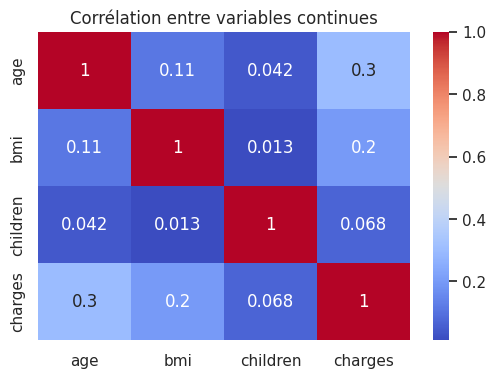

In [14]:
# Heatmap : Corrélation entre variables continues
# Visualise les corrélations entre âge, BMI, nombre d'enfants et charges.
# Observation :
# - Charges corrèlent positivement avec l'âge (corr ~0.3) et le BMI (corr ~0.2-0.3).
# - Très faible corrélation entre charges et le nombre d'enfants (corr ~0.1), donc peu d'impact.
# - Corrélations entre les autres variables continues restent faibles/modérées.
# Conclusion :
# - Les variables continues les plus importantes pour expliquer les charges sont l'âge et le BMI.
# - Children a peu d'effet et pourrait être moins influente dans le modèle.
# - Cette visualisation aide à comprendre quelles variables pourraient être prioritaires pour la modélisation.
plt.figure(figsize=(6,4))
sns.heatmap(df[['age','bmi','children','charges']].corr(), annot=True, cmap='coolwarm')
plt.title("Corrélation entre variables continues")
plt.show()



In [16]:

# SYNTHESE FINALE – ANALYSE EXPLORATOIRE (SEMAINE 1)

# Qualité et structure des données
# - Le jeu de données est globalement propre.
# - Aucune valeur manquante critique n’a été détectée.
# - Un nombre très limité de doublons a été identifié et traité.
# - Les types de variables sont cohérents :
#   numériques (age, bmi, children, charges) et catégorielles (sex, smoker, region).

# Analyse des distributions
# - Charges :
#   Distribution fortement asymétrique à droite avec plusieurs valeurs extrêmes (>50 000$).
#   Ces outliers peuvent fortement influencer un modèle linéaire.
#   Une transformation logarithmique des charges pourra être envisagée par la suite.
#
# - BMI :
#   La majorité des valeurs est comprise entre 20 et 35.
#   Quelques valeurs extrêmes existent mais restent plausibles.
#   Variable exploitable telle quelle, tout en gardant les outliers en mémoire.
#
# - Age :
#   Distribution cohérente entre 18 et 64 ans.
#   Pas de valeurs aberrantes significatives.
#   Variable stable et bien adaptée à la modélisation.

# Relations entre variables
# - Le tabagisme est le facteur le plus discriminant :
#   Les fumeurs ont des charges nettement plus élevées que les non-fumeurs.
#
# - L'âge et le BMI ont un impact positif sur les charges,
#   impact beaucoup plus marqué chez les fumeurs.
#
# - Le nombre d’enfants a une corrélation faible avec les charges.
#
# - Les régions sont relativement équilibrées et n’expliquent pas fortement les charges.

# Enseignements pour la suite du projet
# - Variables clés pour la modélisation :
#   smoker, age, bmi.
# - Présence d’outliers et asymétrie des charges :
#   nécessité d’un scaling et potentiellement d’une transformation log.
# - Ces observations justifient la mise en place d’un pipeline de préparation
#   avant la modélisation (Semaine 2 : baseline et évaluation).
